# 🧪 Quick Test Model Anti-Spoofing trên CelebA-Spoof (Subset 10K)
**Dự án PBL6 — SmartFace Anti-Spoofing System**

Notebook này dùng để **kiểm tra và đánh giá nhanh (Quick Test / Benchmark)** model Face Anti-Spoofing (PyTorch `.pth` hoặc ONNX `.onnx`) đã train trên Kaggle:
- **Tập kiểm thử:** Trích xuất một subset **10,000 ảnh có phân tầng (Stratified)** từ tập test chính thức của CelebA-Spoof (`metas/intra_test/test_label.json`).
- **Cách Stratify:** Đồng bộ 100% với notebook train (`SAMPLE_SEED = 42`, phân tầng theo 3 class: 0: Real, 1: Physical Spoof, 2: Digital Spoof theo nhãn `v[40]`).
- **Tiền xử lý:** Chuẩn hóa theo kiến trúc hệ thống (expanded crop 1.5×, đệm viền `BORDER_REFLECT_101`, CelebA Mean/Std).
- **Chỉ số đánh giá:** Accuracy, AUC, APCER, BPCER, ACER (theo ISO/IEC 30107-3), Confusion Matrix, phân tích False Acceptance / False Rejection.

In [6]:
# Cell 1: Cài đặt và import các thư viện cần thiết
!pip install -q albumentations onnx onnxruntime scikit-learn seaborn matplotlib tabulate

In [7]:


import os, sys, json, time, copy, glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score

try:
    import onnxruntime as ort
    ONNX_AVAILABLE = True
except ImportError:
    ONNX_AVAILABLE = False

# Tránh tranh chấp CPU giữa OpenCV (đa luồng nội bộ) và DataLoader (multi-worker) -> tăng tốc thực tế trên Kaggle
cv2.setNumThreads(0)
torch.backends.cudnn.benchmark = True

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name     : {torch.cuda.get_device_name(0)}")


PyTorch Version : 2.10.0+cu128
CUDA Available  : True
Device Name     : Tesla T4


## ⚙️ 2. Cấu hình đường dẫn Dataset, Model & Tham số kiểm thử
Bạn có thể điều chỉnh đường dẫn dataset và model bên dưới:
- `DATA_ROOT`: Thư mục dataset CelebA-Spoof trên Kaggle.
- `MODEL_PATH`: Đường dẫn file `.pth` hoặc `.onnx` (có thể tải lên qua Kaggle Dataset hoặc lấy từ notebook output).
- `TEST_SUBSET_SIZE`: Mặc định là `10000` ảnh để test nhanh trong ~1-2 phút. Đặt `None` nếu muốn chạy full test set (~67K ảnh).

In [8]:
# ==============================================================================
# Cell 2: Thiết lập đường dẫn trực tiếp (SIÊU TỐC - KHÔNG DÙNG GLOB)
# ==============================================================================
import os, sys, torch

# 1. Đường dẫn Dataset CelebA-Spoof (đã nhận diện chính xác)
DATA_ROOT = "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"
if not os.path.exists(DATA_ROOT):
    # Dự phòng nếu đường dẫn ngắn
    DATA_ROOT = "/kaggle/input/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"

TEST_JSON = os.path.join(DATA_ROOT, "metas/intra_test/test_label.json")
print(f"✅ DATA_ROOT: {DATA_ROOT} (Exists: {os.path.exists(TEST_JSON)})")

# 2. Đường dẫn Model: Tìm CHỈ TRONG dataset model (tuyệt đối không quét CelebA)
MODEL_PATH = "/kaggle/input/datasets/takasugi1303/pbl6-antispoof-models/mnv3_large_3class_best.onnx"
model_dir = "/kaggle/input/pbl6-antispoof-models"

if os.path.exists(model_dir):
    for f in os.listdir(model_dir):
        if f.endswith(".pth") or f.endswith(".onnx"):
            MODEL_PATH = os.path.join(model_dir, f)
            break

# Nếu không thấy trong dataset, thử tìm trong thư mục hiện tại / working
if not MODEL_PATH or not os.path.exists(MODEL_PATH):
    for f in ["best_mnv3_large_3class.pth", "mnv3_large_3class_best.onnx"]:
        if os.path.exists(f):
            MODEL_PATH = f
            break

print(f"✅ MODEL_PATH: {MODEL_PATH}")
if not MODEL_PATH or not os.path.exists(MODEL_PATH):
    print("⚠️ CHƯA TÌM THẤY MODEL! Hãy copy file path từ cột Input bên phải dán thẳng vào: MODEL_PATH = '...'")

# 3. Tham số lấy mẫu
TEST_SUBSET_SIZE = 10000   # 10,000 ảnh Quick Test
SAMPLE_SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Device: {DEVICE}")


✅ DATA_ROOT: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof (Exists: True)
✅ MODEL_PATH: /kaggle/input/datasets/takasugi1303/pbl6-antispoof-models/mnv3_large_3class_best.onnx
✅ Device: cuda


## 📦 3. Định nghĩa Dataset & Chuẩn hóa Tiền xử lý
- **Face Crop:** Đọc bounding box từ file `_BB.txt` tương ứng, chuyển đổi toạ độ về ảnh gốc, mở rộng khung **1.5×** và áp dụng đệm viền `cv2.BORDER_REFLECT_101` tạo ảnh vuông.
- **Normalization:** CelebA mean `[0.5931, 0.4690, 0.4229]` và std `[0.2471, 0.2214, 0.2157]`.
- **Label Mapping:**
  - `0`: Real (Mặt thật)
  - `1`: Physical Spoof (Ảnh in, giấy cắt, mặt nạ,...)
  - `2`: Digital Spoof (Màn hình PC, tablet, điện thoại,...)
  - **Binary PAD Ground Truth:** `0` nếu là Real, `1` nếu là Spoof (Class 1 hoặc Class 2).

In [9]:
# Cell 3: CelebASpoofTestDataset với Preprocessing chuẩn 1.5x Crop
CELEBA_MEAN = [0.5931, 0.4690, 0.4229]
CELEBA_STD = [0.2471, 0.2214, 0.2157]

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=CELEBA_MEAN, std=CELEBA_STD),
    ToTensorV2(),
])

class CelebASpoofTestDataset(Dataset):
    def __init__(self, root_dir, json_path, transform=None):
        self.root_dir = root_dir
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        self.keys = list(self.data.keys())
        self.transform = transform

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        rel_path = self.keys[idx]
        labels = self.data[rel_path]

        img_path = os.path.join(self.root_dir, rel_path)
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h_img, w_img = image.shape[:2]

        # Đọc bbox từ file _BB.txt
        bb_path = os.path.splitext(img_path)[0] + "_BB.txt"
        if os.path.exists(bb_path):
            try:
                with open(bb_path, 'r') as f:
                    parts = f.readline().strip().split()
                if len(parts) >= 4:
                    x, y, w, h = map(float, parts[:4])
                    x = x / 224 * w_img
                    y = y / 224 * h_img
                    w = w / 224 * w_img
                    h = h / 224 * h_img

                    # Expanded crop 1.5x với BORDER_REFLECT_101
                    max_dim = max(w, h)
                    cx, cy = x + w / 2, y + h / 2
                    crop_size = int(max_dim * 1.5)
                    
                    x_start = int(cx - crop_size / 2)
                    y_start = int(cy - crop_size / 2)
                    
                    crop_x1, crop_y1 = max(0, x_start), max(0, y_start)
                    crop_x2, crop_y2 = min(w_img, x_start + crop_size), min(h_img, y_start + crop_size)
                    
                    top_pad = int(max(0, -y_start))
                    left_pad = int(max(0, -x_start))
                    bottom_pad = int(max(0, (y_start + crop_size) - h_img))
                    right_pad = int(max(0, (x_start + crop_size) - w_img))
                    
                    if crop_x2 > crop_x1 and crop_y2 > crop_y1:
                        cropped_img = image[crop_y1:crop_y2, crop_x1:crop_x2, :]
                    else:
                        cropped_img = np.zeros((0, 0, 3), dtype=image.dtype)
                    
                    image = cv2.copyMakeBorder(cropped_img, top_pad, bottom_pad, left_pad, right_pad, cv2.BORDER_REFLECT_101)
                    if image.shape[0] != crop_size or image.shape[1] != crop_size:
                        image = cv2.resize(image, (crop_size, crop_size), interpolation=cv2.INTER_AREA)
            except (ValueError, OSError):
                pass

        label_raw = int(labels[40])
        if label_raw == 0:
            label_3c = 0  # Real
        elif label_raw in [1, 2, 3, 4, 5, 6, 7]:
            label_3c = 1  # Physical Spoof
        else:
            label_3c = 2  # Digital Spoof

        # Binary label cho PAD: 0: Real, 1: Spoof
        label_bin = 0 if label_3c == 0 else 1

        if self.transform:
            augmented = self.transform(image=image)
            tensor_img = augmented['image']
        else:
            tensor_img = ToTensorV2()(image=image)['image']

        return tensor_img, label_bin, label_3c, rel_path

## 📊 4. Lấy mẫu phân tầng (Stratified Sampling) đúng 10K ảnh
Đảm bảo tỷ lệ 3 class trong tập 10,000 ảnh phản ánh chính xác phân phối của tập Test CelebA-Spoof gốc, sử dụng cùng `SAMPLE_SEED = 42`:

In [10]:
# Cell 4: Tạo Stratified Test Subset đồng bộ với notebook train
def _label_of(v):
    lr = int(v[40])
    if lr == 0:
        return 0
    elif lr in [1, 2, 3, 4, 5, 6, 7]:
        return 1
    else:
        return 2

print(f"Đang đọc Test Metadata từ: {TEST_JSON}")
test_base_dataset = CelebASpoofTestDataset(DATA_ROOT, TEST_JSON, transform=val_transform)
total_test_samples = len(test_base_dataset)
print(f"Tổng số mẫu trong CelebA-Spoof Test Set: {total_test_samples:,} ảnh")

# Lấy nhãn 3 class cho toàn bộ test set
all_test_labels = np.array([_label_of(test_base_dataset.data[k]) for k in test_base_dataset.keys])

if TEST_SUBSET_SIZE is not None and TEST_SUBSET_SIZE < total_test_samples:
    rng = np.random.default_rng(SAMPLE_SEED)
    selected_indices = []

    for c in [0, 1, 2]:
        c_indices = np.where(all_test_labels == c)[0]
        n_sample_c = int(round(TEST_SUBSET_SIZE * len(c_indices) / total_test_samples))
        n_sample_c = min(n_sample_c, len(c_indices))
        chosen = rng.choice(c_indices, size=n_sample_c, replace=False)
        selected_indices.extend(chosen.tolist())

    rng.shuffle(selected_indices)
    test_dataset = Subset(test_base_dataset, selected_indices)
    subset_labels = all_test_labels[selected_indices]
    print(f"--> Đã tạo Quick Test Subset: {len(test_dataset):,} ảnh (Stratified, Seed={SAMPLE_SEED})")
else:
    test_dataset = test_base_dataset
    subset_labels = all_test_labels
    print(f"--> Sử dụng TOÀN BỘ Test Set: {len(test_dataset):,} ảnh")

# Thống kê phân phối
class_names = ["0: Real Face", "1: Physical Spoof", "2: Digital Spoof"]
table_dist = []
for c in [0, 1, 2]:
    cnt = np.sum(subset_labels == c)
    pct = cnt / len(test_dataset) * 100
    table_dist.append([class_names[c], f"{cnt:,}", f"{pct:.2f}%"])

print("\n" + tabulate(table_dist, headers=["Class", "Số lượng", "Tỷ lệ"], tablefmt="fancy_grid"))

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

Đang đọc Test Metadata từ: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/test_label.json
Tổng số mẫu trong CelebA-Spoof Test Set: 67,170 ảnh
--> Đã tạo Quick Test Subset: 10,000 ảnh (Stratified, Seed=42)

╒═══════════════════╤════════════╤═════════╕
│ Class             │ Số lượng   │ Tỷ lệ   │
╞═══════════════════╪════════════╪═════════╡
│ 0: Real Face      │ 2,966      │ 29.66%  │
├───────────────────┼────────────┼─────────┤
│ 1: Physical Spoof │ 5,284      │ 52.84%  │
├───────────────────┼────────────┼─────────┤
│ 2: Digital Spoof  │ 1,750      │ 17.50%  │
╘═══════════════════╧════════════╧═════════╛


## 🧠 5. Khởi tạo Kiến trúc & Nạp Model Checkpoint
Hỗ trợ tự động nhận dạng:
1. **PyTorch Checkpoint (`.pth`)**: Nạp weights vào kiến trúc `AntiSpoofMobileNetV3` (với classifier head 3 class).
2. **ONNX Model (`.onnx`)**: Nạp trực tiếp qua `onnxruntime` engine.

In [11]:
# Cell 5: Model Definition & Checkpoint Loader
class AntiSpoofMobileNetV3(nn.Module):
    def __init__(self, dropout_rate=0.5, num_classes=3):
        super(AntiSpoofMobileNetV3, self).__init__()
        # weights=None: checkpoint của bạn sẽ ghi đè toàn bộ trọng số ngay sau đó,
        # nên không cần tải pretrained ImageNet (tốn thời gian và LỖI nếu tắt Internet trên Kaggle)
        backbone = models.mobilenet_v3_large(weights=None)

        self.features = backbone.features
        self.avgpool = backbone.avgpool
        in_features = backbone.classifier[0].in_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 1280),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class ModelEvaluator:
    def __init__(self, model_path, device):
        self.model_path = model_path
        self.device = device
        self.is_onnx = model_path.endswith(".onnx")

        if not os.path.exists(model_path):
            raise FileNotFoundError(
                f"❌ Không tìm thấy file model tại: '{model_path}'.\n"
                f"   Hãy 'Add Data' checkpoint của bạn trên Kaggle rồi cập nhật lại biến MODEL_PATH ở Cell 2."
            )

        print(f"Đang tải model từ: {model_path}")
        if self.is_onnx:
            assert ONNX_AVAILABLE, "onnxruntime chưa được cài đặt!"
            providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if device.type == 'cuda' else ['CPUExecutionProvider']
            self.session = ort.InferenceSession(model_path, providers=providers)
            self.input_name = self.session.get_inputs()[0].name
            print(f"✅ ONNX Session sẵn sàng với providers: {self.session.get_providers()}")
        else:
            self.model = AntiSpoofMobileNetV3(dropout_rate=0.5, num_classes=3).to(device)
            ckpt = torch.load(model_path, map_location=device)

            # Xử lý linh hoạt format checkpoint: dictionary bọc hoặc state_dict thuần
            if isinstance(ckpt, dict):
                if "model_state_dict" in ckpt:
                    state_dict = ckpt["model_state_dict"]
                elif "best_model_state" in ckpt:
                    state_dict = ckpt["best_model_state"]
                elif "state_dict" in ckpt:
                    state_dict = ckpt["state_dict"]
                else:
                    state_dict = ckpt
            else:
                state_dict = ckpt

            # Loại bỏ prefix nếu có (vd: 'module.')
            clean_state_dict = {}
            for k, v in state_dict.items():
                new_k = k.replace("module.", "")
                clean_state_dict[new_k] = v

            load_result = self.model.load_state_dict(clean_state_dict, strict=False)
            if load_result.missing_keys or load_result.unexpected_keys:
                print(f"⚠️ CẢNH BÁO: load_state_dict không khớp hoàn toàn (strict=False)!")
                print(f"   - Missing keys ({len(load_result.missing_keys)}): {load_result.missing_keys[:5]}{'...' if len(load_result.missing_keys) > 5 else ''}")
                print(f"   - Unexpected keys ({len(load_result.unexpected_keys)}): {load_result.unexpected_keys[:5]}{'...' if len(load_result.unexpected_keys) > 5 else ''}")
                print(f"   Nếu số lượng lớn, kiểm tra lại kiến trúc model có đúng khớp với checkpoint không.")
            self.model.eval()
            print("✅ PyTorch Model loaded và chuyển sang chế độ eval()")

    def predict_batch(self, tensor_batch):
        if self.is_onnx:
            inp = tensor_batch.cpu().numpy().astype(np.float32)
            outputs = self.session.run(None, {self.input_name: inp})[0]
            return torch.from_numpy(outputs)
        else:
            with torch.no_grad():
                outputs = self.model(tensor_batch.to(self.device))
            return outputs.cpu()

evaluator = ModelEvaluator(MODEL_PATH, DEVICE)


Đang tải model từ: /kaggle/input/datasets/takasugi1303/pbl6-antispoof-models/mnv3_large_3class_best.onnx
✅ ONNX Session sẵn sàng với providers: ['CPUExecutionProvider']


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


## ⚡ 6. Thực thi Inference trên tập Quick Test
- Tính toán logits cho từng ảnh.
- `real_logit = output[0]`
- `spoof_logit = max(output[1:])`
- `logit_diff = real_logit - spoof_logit` (Score càng lớn thì độ tin cậy Real càng cao, càng âm thì càng nghiêng về Spoof).
- Đo lường throughput và latency trung bình.

In [12]:
# Cell 6: Chạy Inference trên TestLoader
y_true_bin = []
y_true_3c  = []
y_scores   = []
y_relpaths = []

start_time = time.time()

for images, labels_bin, labels_3c, rel_paths in tqdm(test_loader, desc="Quick Testing"):
    outputs = evaluator.predict_batch(images)  # [B, 3]

    real_logits  = outputs[:, 0]
    spoof_logits = torch.max(outputs[:, 1:], dim=1)[0]
    logit_diff   = (real_logits - spoof_logits).numpy()

    y_true_bin.extend(labels_bin.numpy().tolist())
    y_true_3c.extend(labels_3c.numpy().tolist())
    y_scores.extend(logit_diff.tolist())
    y_relpaths.extend(rel_paths)

total_eval_time = time.time() - start_time
y_true_bin = np.array(y_true_bin)
y_true_3c  = np.array(y_true_3c)
y_scores   = np.array(y_scores)

n_total = len(y_true_bin)
latency_per_img = (total_eval_time / n_total) * 1000
fps = n_total / total_eval_time

print(f"\n⏱️ Tổng thời gian inference : {total_eval_time:.2f}s ({n_total} ảnh)")
print(f"⚡ Tốc độ trung bình         : {latency_per_img:.2f} ms/ảnh ({fps:.1f} FPS)")

Quick Testing: 100%|██████████| 79/79 [02:55<00:00,  2.22s/it]


⏱️ Tổng thời gian inference : 175.33s (10000 ảnh)
⚡ Tốc độ trung bình         : 17.53 ms/ảnh (57.0 FPS)


## 📈 7. Đánh giá Chỉ số PAD theo Tiêu chuẩn ISO/IEC 30107-3
Các chỉ số sinh trắc học Face Anti-Spoofing:
- **APCER (Attack Presentation Classification Error Rate):** Tỷ lệ mẫu Spoof bị nhận nhầm thành Real (Lỗ hổng bảo mật).
- **BPCER (Bona Fide Presentation Classification Error Rate):** Tỷ lệ mẫu Real bị từ chối nhầm là Spoof (Gây phiền hà cho người dùng).
- **ACER (Average Classification Error Rate):** `(APCER + BPCER) / 2`.
- **Operating Points được đánh giá:**
  1. `Threshold = 0.0` (Ngưỡng argmax mặc định của model)
  2. `Best ACER Threshold` (Ngưỡng tối ưu hóa ACER tổng thể)
  3. `Security @ APCER ≤ 1%` (Bảo mật cao)
  4. `Security @ APCER ≤ 5%` (Cân bằng)

In [13]:
# Cell 7: Tính toán Metrics toàn diện & Sweep Threshold
# y_scores là logit_diff = real_logit - spoof_logit
# Quy tắc quyết định:
#   Nếu logit_diff >= threshold  ==> Dự đoán Real (0)
#   Nếu logit_diff <  threshold  ==> Dự đoán Spoof (1)

def compute_pad_metrics(y_true, scores, threshold):
    # y_pred_spoof = 1 nếu score < threshold (vì score thấp là spoof)
    preds_spoof = (scores < threshold).astype(int)
    
    # 0: Real, 1: Spoof
    is_real  = (y_true == 0)
    is_spoof = (y_true == 1)
    
    n_real  = np.sum(is_real)
    n_spoof = np.sum(is_spoof)
    
    # APCER: Spoof bị dự đoán thành Real (preds_spoof == 0 trên tập spoof)
    false_accept_spoof = np.sum((preds_spoof == 0) & is_spoof)
    apcer = false_accept_spoof / n_spoof if n_spoof > 0 else 0.0
    
    # BPCER: Real bị dự đoán thành Spoof (preds_spoof == 1 trên tập real)
    false_reject_real = np.sum((preds_spoof == 1) & is_real)
    bpcer = false_reject_real / n_real if n_real > 0 else 0.0
    
    acer = (apcer + bpcer) / 2.0
    acc = np.mean((preds_spoof == 1) == is_spoof)
    
    return {
        "threshold": threshold,
        "acc": acc,
        "apcer": apcer,
        "bpcer": bpcer,
        "acer": acer,
        "n_fa": false_accept_spoof,
        "n_fr": false_reject_real
    }

# 1. Tính AUC (cho bài toán phân biệt Real vs Spoof)
# Với roc_curve của sklearn, nhãn 1 thường là positive class. Ở đây coi Spoof (1) là positive -> điểm phân loại spoof là -y_scores
fpr, tpr, roc_thresholds = roc_curve(y_true_bin, -y_scores)
roc_auc = auc(fpr, tpr)

# 2. Sweep tìm Best ACER và các Operating Points
threshold_candidates = np.linspace(np.percentile(y_scores, 1), np.percentile(y_scores, 99), 500)
sweep_results = [compute_pad_metrics(y_true_bin, y_scores, th) for th in threshold_candidates]

best_acer_res = min(sweep_results, key=lambda x: x["acer"])
default_res   = compute_pad_metrics(y_true_bin, y_scores, 0.0)

# Tìm ngưỡng cho APCER <= 1%
candidates_apcer_1 = [r for r in sweep_results if r["apcer"] <= 0.01]
res_apcer_1 = min(candidates_apcer_1, key=lambda x: x["bpcer"]) if candidates_apcer_1 else None

# Tìm ngưỡng cho APCER <= 5%
candidates_apcer_5 = [r for r in sweep_results if r["apcer"] <= 0.05]
res_apcer_5 = min(candidates_apcer_5, key=lambda x: x["bpcer"]) if candidates_apcer_5 else None

# Hiển thị bảng tổng hợp
summary_rows = [
    ["ROC AUC Score", f"{roc_auc:.4f}", "-", "-", "-", "-"],
    ["Default (Thresh=0.0)", f"{default_res['acc']*100:.2f}%", f"{default_res['apcer']*100:.2f}%", f"{default_res['bpcer']*100:.2f}%", f"{default_res['acer']*100:.2f}%", f"0.000"],
    ["Best ACER Operating Point", f"{best_acer_res['acc']*100:.2f}%", f"{best_acer_res['apcer']*100:.2f}%", f"{best_acer_res['bpcer']*100:.2f}%", f"{best_acer_res['acer']*100:.2f}%", f"{best_acer_res['threshold']:.3f}"],
]

if res_apcer_5:
    summary_rows.append(["Security (APCER ≤ 5%)", f"{res_apcer_5['acc']*100:.2f}%", f"{res_apcer_5['apcer']*100:.2f}%", f"{res_apcer_5['bpcer']*100:.2f}%", f"{res_apcer_5['acer']*100:.2f}%", f"{res_apcer_5['threshold']:.3f}"])
if res_apcer_1:
    summary_rows.append(["High Security (APCER ≤ 1%)", f"{res_apcer_1['acc']*100:.2f}%", f"{res_apcer_1['apcer']*100:.2f}%", f"{res_apcer_1['bpcer']*100:.2f}%", f"{res_apcer_1['acer']*100:.2f}%", f"{res_apcer_1['threshold']:.3f}"])

print("\n" + tabulate(summary_rows, headers=["Operating Point", "Accuracy", "APCER (Spoof lọt)", "BPCER (Real bị chặn)", "ACER", "Threshold (Logit Diff)"], tablefmt="fancy_grid"))


╒════════════════════════════╤════════════╤═════════════════════╤════════════════════════╤════════╤══════════════════════════╕
│ Operating Point            │ Accuracy   │ APCER (Spoof lọt)   │ BPCER (Real bị chặn)   │ ACER   │ Threshold (Logit Diff)   │
╞════════════════════════════╪════════════╪═════════════════════╪════════════════════════╪════════╪══════════════════════════╡
│ ROC AUC Score              │ 0.9734     │ -                   │ -                      │ -      │ -                        │
├────────────────────────────┼────────────┼─────────────────────┼────────────────────────┼────────┼──────────────────────────┤
│ Default (Thresh=0.0)       │ 89.86%     │ 14.19%              │ 0.54%                  │ 7.36%  │ 0.000                    │
├────────────────────────────┼────────────┼─────────────────────┼────────────────────────┼────────┼──────────────────────────┤
│ Best ACER Operating Point  │ 94.83%     │ 6.68%               │ 1.58%                  │ 4.13%  │ 2.729     

## 🔍 8. Đánh giá chi tiết theo từng loại Spoof (Physical vs Digital)
So sánh khả năng chống chịu giữa **Physical Spoof** (In giấy, poster, mặt nạ) và **Digital Spoof** (Màn hình máy tính, điện thoại, tablet) tại Best ACER threshold:

In [14]:
# Cell 8: Phân tích Attack Breakdown
best_th = best_acer_res['threshold']
preds_spoof = (y_scores < best_th).astype(int)

# Nhãn: 0: Real, 1: Physical Spoof, 2: Digital Spoof
idx_real     = np.where(y_true_3c == 0)[0]
idx_physical = np.where(y_true_3c == 1)[0]
idx_digital  = np.where(y_true_3c == 2)[0]

# Tỷ lệ lọt (APCER riêng từng loại)
fa_physical = np.sum(preds_spoof[idx_physical] == 0)
apcer_physical = fa_physical / len(idx_physical) * 100 if len(idx_physical) > 0 else 0

fa_digital = np.sum(preds_spoof[idx_digital] == 0)
apcer_digital = fa_digital / len(idx_digital) * 100 if len(idx_digital) > 0 else 0

# Tỷ lệ từ chối nhầm Real (BPCER)
fr_real = np.sum(preds_spoof[idx_real] == 1)
bpcer_real = fr_real / len(idx_real) * 100 if len(idx_real) > 0 else 0

breakdown_table = [
    ["Physical Spoof (Class 1)", f"{len(idx_physical):,}", f"{fa_physical:,}", f"{apcer_physical:.2f}%"],
    ["Digital Spoof (Class 2)", f"{len(idx_digital):,}", f"{fa_digital:,}", f"{apcer_digital:.2f}%"],
    ["Real Face (Bona Fide)", f"{len(idx_real):,}", f"{fr_real:,} (bị chặn)", f"{bpcer_real:.2f}%"]
]

print(tabulate(breakdown_table, headers=["Attack Category", "Tổng số mẫu", "Số ca nhận sai", "Error Rate"], tablefmt="fancy_grid"))

╒══════════════════════════╤═══════════════╤══════════════════╤══════════════╕
│ Attack Category          │ Tổng số mẫu   │ Số ca nhận sai   │ Error Rate   │
╞══════════════════════════╪═══════════════╪══════════════════╪══════════════╡
│ Physical Spoof (Class 1) │ 5,284         │ 463              │ 8.76%        │
├──────────────────────────┼───────────────┼──────────────────┼──────────────┤
│ Digital Spoof (Class 2)  │ 1,750         │ 7                │ 0.40%        │
├──────────────────────────┼───────────────┼──────────────────┼──────────────┤
│ Real Face (Bona Fide)    │ 2,966         │ 47 (bị chặn)     │ 1.58%        │
╘══════════════════════════╧═══════════════╧══════════════════╧══════════════╛


## 📊 9. Trực quan hóa Biểu đồ Phân phối, ROC Curve & Confusion Matrix

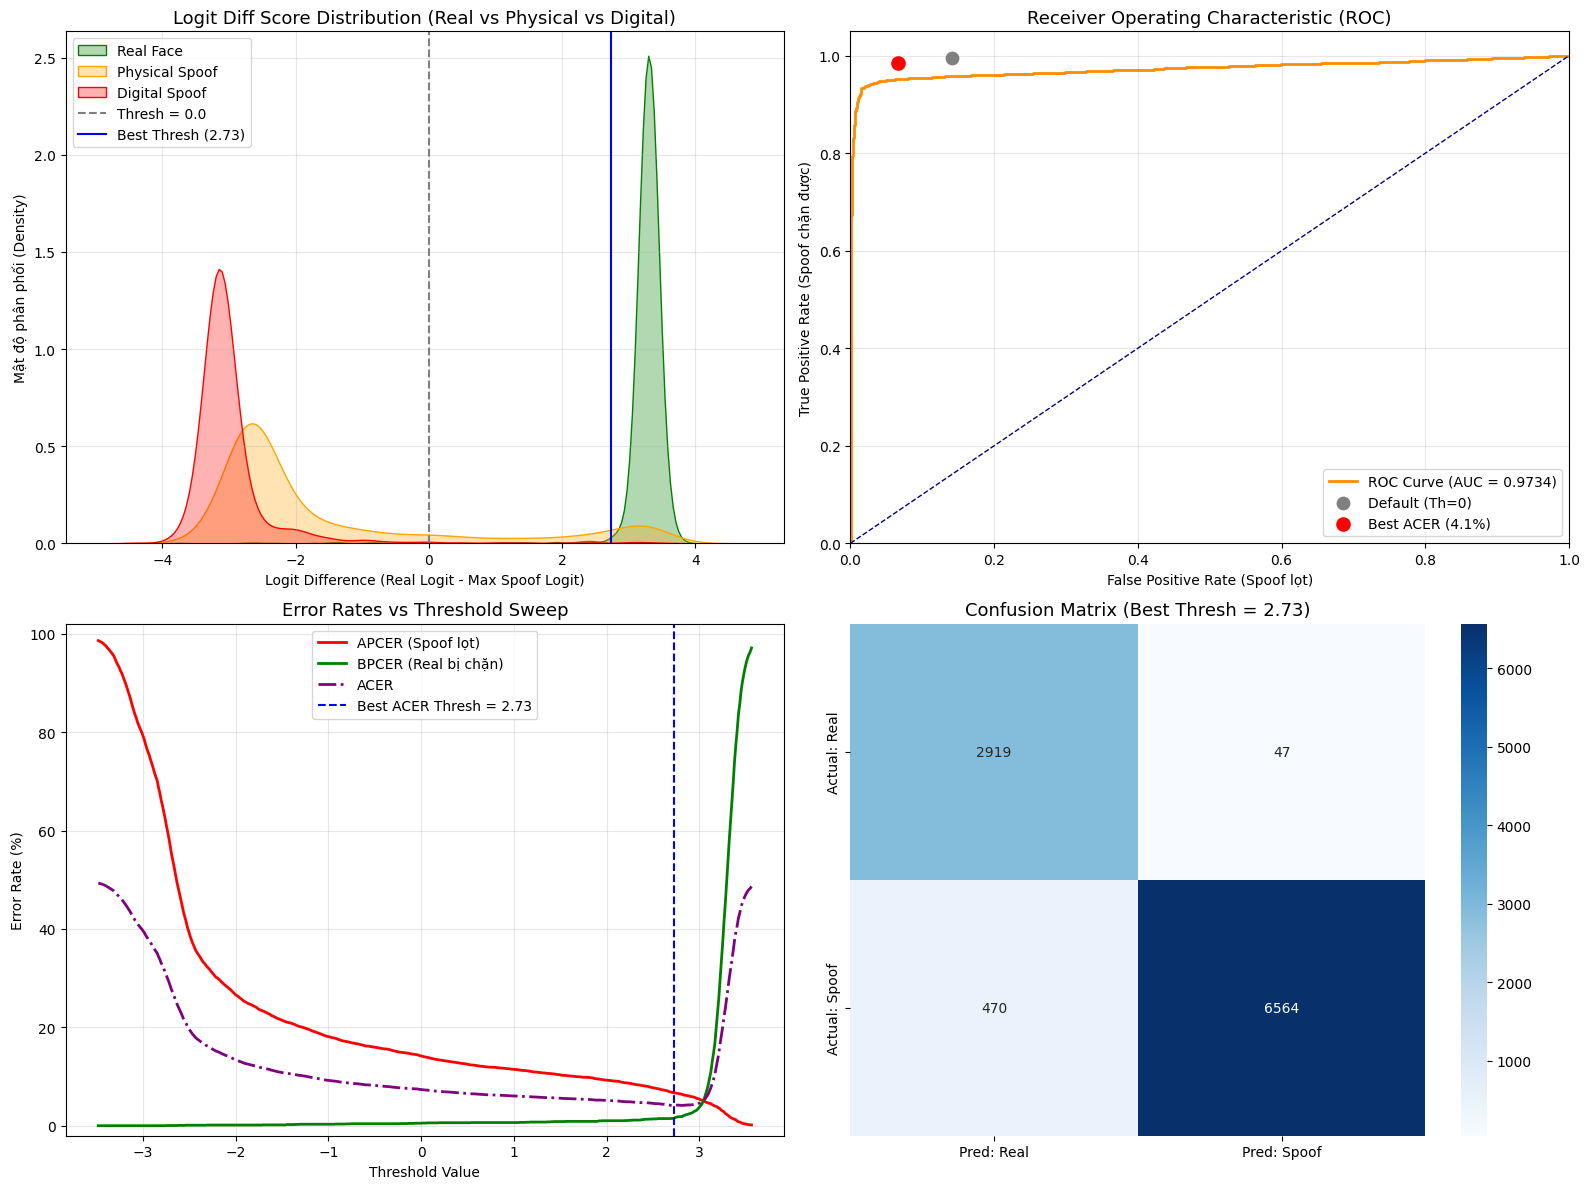

In [15]:
# Cell 9: Vẽ biểu đồ đánh giá
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Phân phối Logit Diff của 3 Class
sns.kdeplot(y_scores[idx_real], ax=axes[0, 0], label="Real Face", fill=True, color="green", alpha=0.3)
sns.kdeplot(y_scores[idx_physical], ax=axes[0, 0], label="Physical Spoof", fill=True, color="orange", alpha=0.3)
sns.kdeplot(y_scores[idx_digital], ax=axes[0, 0], label="Digital Spoof", fill=True, color="red", alpha=0.3)
axes[0, 0].axvline(0.0, color="gray", linestyle="--", label="Thresh = 0.0")
axes[0, 0].axvline(best_th, color="blue", linestyle="-", label=f"Best Thresh ({best_th:.2f})")
axes[0, 0].set_title("Logit Diff Score Distribution (Real vs Physical vs Digital)", fontsize=13)
axes[0, 0].set_xlabel("Logit Difference (Real Logit - Max Spoof Logit)")
axes[0, 0].set_ylabel("Mật độ phân phối (Density)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC Curve
axes[0, 1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[0, 1].plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
axes[0, 1].scatter([default_res['apcer']], [1 - default_res['bpcer']], color="gray", s=80, zorder=5, label="Default (Th=0)")
axes[0, 1].scatter([best_acer_res['apcer']], [1 - best_acer_res['bpcer']], color="red", s=90, zorder=5, label=f"Best ACER ({best_acer_res['acer']*100:.1f}%)")
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel("False Positive Rate (Spoof lọt)")
axes[0, 1].set_ylabel("True Positive Rate (Spoof chặn được)")
axes[0, 1].set_title("Receiver Operating Characteristic (ROC)", fontsize=13)
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Rates theo Threshold
ths = [r["threshold"] for r in sweep_results]
apcers = [r["apcer"] * 100 for r in sweep_results]
bpcers = [r["bpcer"] * 100 for r in sweep_results]
acers  = [r["acer"] * 100 for r in sweep_results]

axes[1, 0].plot(ths, apcers, label="APCER (Spoof lọt)", color="red", lw=2)
axes[1, 0].plot(ths, bpcers, label="BPCER (Real bị chặn)", color="green", lw=2)
axes[1, 0].plot(ths, acers,  label="ACER", color="purple", lw=2, linestyle="-.")
axes[1, 0].axvline(best_th, color="blue", linestyle="--", label=f"Best ACER Thresh = {best_th:.2f}")
axes[1, 0].set_title("Error Rates vs Threshold Sweep", fontsize=13)
axes[1, 0].set_xlabel("Threshold Value")
axes[1, 0].set_ylabel("Error Rate (%)")
axes[1, 0].set_ylim([-2, 102])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Confusion Matrix tại Best ACER
cm = confusion_matrix(y_true_bin, preds_spoof)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1],
            xticklabels=["Pred: Real", "Pred: Spoof"],
            yticklabels=["Actual: Real", "Actual: Spoof"])
axes[1, 1].set_title(f"Confusion Matrix (Best Thresh = {best_th:.2f})", fontsize=13)

plt.tight_layout()
plt.savefig("quick_test_evaluation_plots.png", dpi=300)
plt.show()

## 🔍 10. Phân tích các ca dự đoán sai nghiêm trọng nhất (Worst Failure Cases)
- **Worst False Acceptance:** Mẫu Spoof bị model dự đoán là Real với logit score cao nhất.
- **Worst False Rejection:** Mẫu Real bị model nhầm là Spoof với logit score âm nặng nhất.

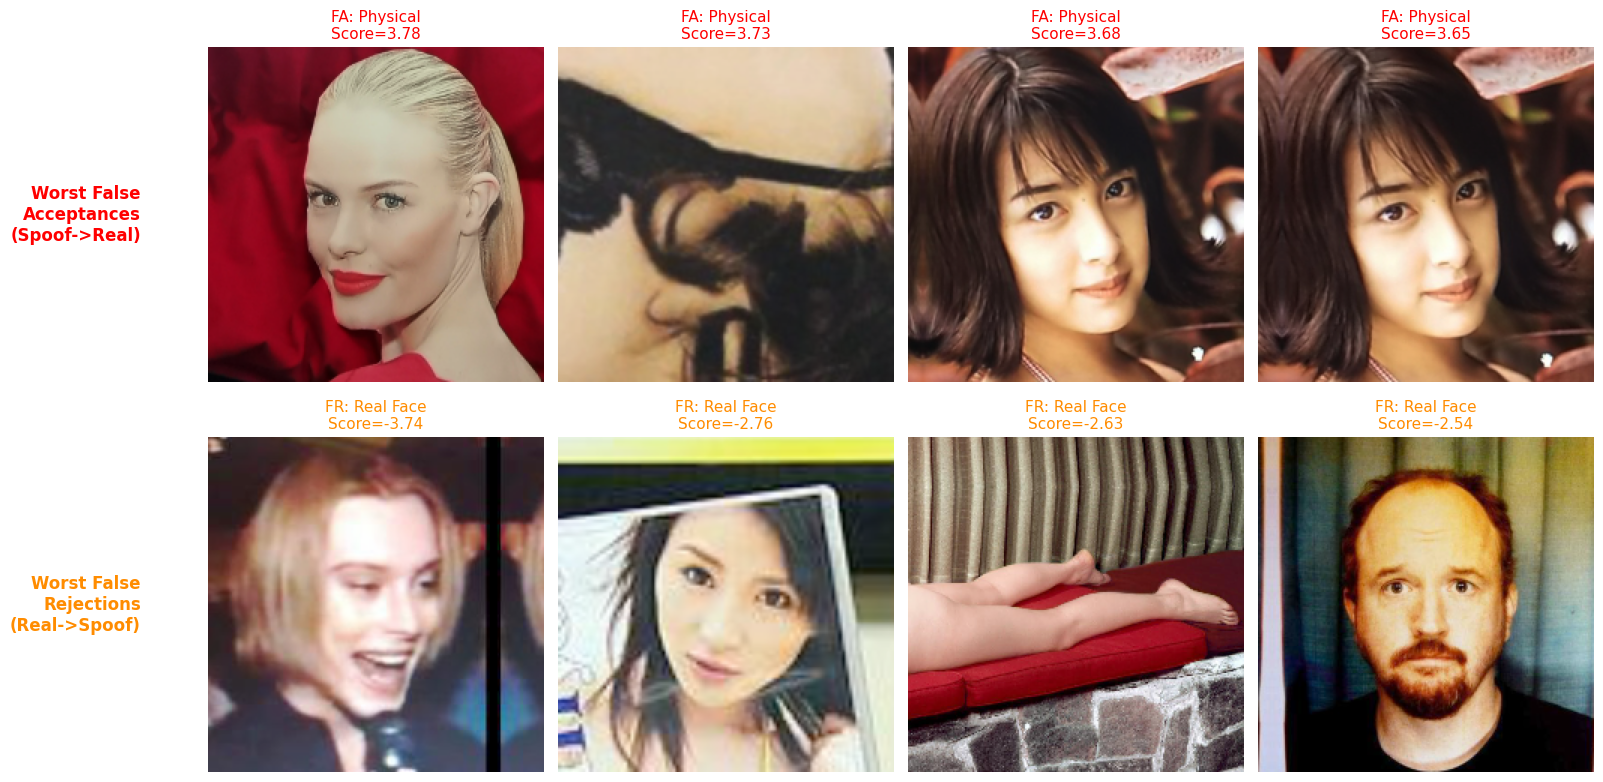

In [16]:
# Cell 10: Hiển thị các ca lỗi tiêu biểu
# False Acceptance: Ground Truth là Spoof (y_true_bin == 1) nhưng score rất cao
spoof_indices = np.where(y_true_bin == 1)[0]
worst_fa_idx = spoof_indices[np.argsort(-y_scores[spoof_indices])[:4]]

# False Rejection: Ground Truth là Real (y_true_bin == 0) nhưng score rất thấp
real_indices = np.where(y_true_bin == 0)[0]
worst_fr_idx = real_indices[np.argsort(y_scores[real_indices])[:4]]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, idx in enumerate(worst_fa_idx):
    img_tensor, _, _, path = test_dataset[idx]
    # Denormalize để hiển thị
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * CELEBA_STD + CELEBA_MEAN
    img_np = np.clip(img_np, 0, 1)
    
    cls_str = "Physical" if y_true_3c[idx] == 1 else "Digital"
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"FA: {cls_str}\nScore={y_scores[idx]:.2f}", color="red", fontsize=11)
    axes[0, i].axis("off")

for i, idx in enumerate(worst_fr_idx):
    img_tensor, _, _, path = test_dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * CELEBA_STD + CELEBA_MEAN
    img_np = np.clip(img_np, 0, 1)
    
    axes[1, i].imshow(img_np)
    axes[1, i].set_title(f"FR: Real Face\nScore={y_scores[idx]:.2f}", color="darkorange", fontsize=11)
    axes[1, i].axis("off")

axes[0, 0].text(-0.2, 0.5, "Worst False\nAcceptances\n(Spoof->Real)", transform=axes[0, 0].transAxes,
                va='center', ha='right', fontsize=12, fontweight='bold', color='red')
axes[1, 0].text(-0.2, 0.5, "Worst False\nRejections\n(Real->Spoof)", transform=axes[1, 0].transAxes,
                va='center', ha='right', fontsize=12, fontweight='bold', color='darkorange')

plt.tight_layout()
plt.savefig("worst_failure_cases.png", dpi=300)
plt.show()

In [18]:
# Cell 10b: Debug - kiểm tra chi tiết đường dẫn & nhãn thô của các ca lỗi nghiêm trọng nhất
print("=" * 90)
print("🔍 CHI TIẾT CÁC CA FALSE ACCEPTANCE (Ground Truth = Spoof, model đoán Real)")
print("=" * 90)
for i, idx in enumerate(worst_fa_idx):
    rel_path = y_relpaths[idx]
    raw_label = test_base_dataset.data[rel_path]
    attack_id = int(raw_label[40])
    full_img_path = os.path.join(DATA_ROOT, rel_path)
    print(f"[{i+1}] Score={y_scores[idx]:.2f} | v[40] (Attack ID)={attack_id} "
          f"| 3-class label={y_true_3c[idx]}")
    print(f"     Path ảnh : {full_img_path}")
    print(f"     Tồn tại  : {os.path.exists(full_img_path)}")
    print()

print("=" * 90)
print("🔍 CHI TIẾT CÁC CA FALSE REJECTION (Ground Truth = Real, model đoán Spoof)")
print("=" * 90)
for i, idx in enumerate(worst_fr_idx):
    rel_path = y_relpaths[idx]
    raw_label = test_base_dataset.data[rel_path]
    attack_id = int(raw_label[40])
    full_img_path = os.path.join(DATA_ROOT, rel_path)
    bb_path = os.path.splitext(full_img_path)[0] + "_BB.txt"
    print(f"[{i+1}] Score={y_scores[idx]:.2f} | v[40] (Attack ID)={attack_id} "
          f"| 3-class label={y_true_3c[idx]}")
    print(f"     Path ảnh : {full_img_path}")
    print(f"     File BB  : {bb_path} (Exists: {os.path.exists(bb_path)})")
    if os.path.exists(bb_path):
        with open(bb_path, "r") as f:
            print(f"     Nội dung BB: {f.readline().strip()}")
    print()

🔍 CHI TIẾT CÁC CA FALSE ACCEPTANCE (Ground Truth = Spoof, model đoán Real)
[1] Score=3.78 | v[40] (Attack ID)=5 | 3-class label=1
     Path ảnh : /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/test/5184/spoof/503204.png
     Tồn tại  : True

[2] Score=3.73 | v[40] (Attack ID)=3 | 3-class label=1
     Path ảnh : /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/test/6454/spoof/507541.png
     Tồn tại  : True

[3] Score=3.68 | v[40] (Attack ID)=7 | 3-class label=1
     Path ảnh : /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/test/6657/spoof/513684.png
     Tồn tại  : True

[4] Score=3.65 | v[40] (Attack ID)=7 | 3-class label=1
     Path ảnh : /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/test/6657/spoof/529769.png
     Tồn tại  : True

🔍 CHI TIẾT CÁ

## 💾 11. Xuất Báo cáo Kết quả Kiểm thử
Lưu toàn bộ metrics chi tiết ra file JSON và CSV để bạn có thể tải về máy kiểm tra hoặc so sánh giữa các phiên bản model:

In [17]:
# Cell 11: Export kết quả kiểm thử
export_data = {
    "model_path": MODEL_PATH,
    "test_subset_size": len(test_dataset),
    "sample_seed": SAMPLE_SEED,
    "roc_auc": float(roc_auc),
    "latency_ms_per_image": float(latency_per_img),
    "fps": float(fps),
    "default_threshold_0": {k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in default_res.items()},
    "best_acer_threshold": {k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in best_acer_res.items()},
    "breakdown": {
        "physical_spoof_samples": int(len(idx_physical)),
        "physical_apcer_pct": float(apcer_physical),
        "digital_spoof_samples": int(len(idx_digital)),
        "digital_apcer_pct": float(apcer_digital),
        "real_samples": int(len(idx_real)),
        "real_bpcer_pct": float(bpcer_real),
    }
}

with open("quick_test_summary.json", "w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=4, ensure_ascii=False)

df_sweep = pd.DataFrame(sweep_results)
df_sweep.to_csv("threshold_sweep_results.csv", index=False)

print("✅ Đã xuất thành công:")
print("   - quick_test_summary.json")
print("   - threshold_sweep_results.csv")
print("   - quick_test_evaluation_plots.png")
print("   - worst_failure_cases.png")

✅ Đã xuất thành công:
   - quick_test_summary.json
   - threshold_sweep_results.csv
   - quick_test_evaluation_plots.png
   - worst_failure_cases.png
